In [1]:
import random
from copy import deepcopy
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from torch_geometric.data import Data
from tqdm import tqdm

import barostat_parameters
from graph_utils import prepare_traj
from itpo_weights import DatasetType
from pressure import compute_total_stress
from simulator_model import Model as VelocityModel
from training_utils import freeze_normalizer
from utils import (
    calc_p_ratio_box_tensor,
    get_rollout,
    load_and_split_dataset,
)


/home/sergey/work/gnn/GNNInverseDesign/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
poisson_buckets = [
    {"max": 0.1, "count": 10},                # P < 0.1
    {"min": 0.1, "max": 0.2, "count": 10},    # 0.1 <= P < 0.2
    {"min": 0.2, "count": 10}                 # P >= 0.2
]

dataset_type = DatasetType.StiffAngles

train_files, val_files, test_files = load_and_split_dataset(
    # registry_path="./data_mini/data_registry_mini.csv",
    # registry_path="./data/data_registry.csv",
    registry_path="./data_reid_with_angles/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(1.0, 0.0, 0.0),
    seed=42
)

# Load actual data
data = {
    'train': {},
    'val' : {},
    'test' : {},
}

max_sim_len = 500
stride = 5
print(f"Loading data with max simulation length of {max_sim_len}...")
for key in data.keys():
    if key == 'train':
        # data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(train_files, desc=f"{key:<5} data")]
        data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(train_files, desc=f"{key:<5} data")]
    elif key == 'val':
        # data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(val_files, desc=f"{key:<5} data")]
        data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(val_files, desc=f"{key:<5} data")]
    elif key == 'test':
        # data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(test_files, desc=f"{key:<5} data")]
        data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(test_files, desc=f"{key:<5} data")]
    else:
        raise ValueError(f"Unexpected key in data dictionary: {key}. ")

# print("\nPreparing data...")
# for data_type, sims in data.items():
#     prepared = []
#     for sim in tqdm(sims, desc=f"{data_type:<5} data"):
#         prepared_sim = prepare_traj(sim, calc_angles=False)
#         prepared.append(prepared_sim)
#     data[data_type] = prepared

print(f"\nTrain data: {len(data['train'])} sims.")
print(f"Val data:   {len(data['val'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")


Loading data with max simulation length of 500...


train data:   0%|          | 0/30 [00:00<?, ?it/s]

train data: 100%|██████████| 30/30 [00:02<00:00, 13.23it/s]
val   data: 0it [00:00, ?it/s]
test  data: 0it [00:00, ?it/s]


Train data: 30 sims.
Val data:   0 sims.
Test data:  0 sims.


In [3]:
Lx = []
for sim in data["train"][:1]:
    x_evo = [g.box.x for g in sim]
    Lx.append(x_evo)

In [4]:
deltas_percent = []
deltas = []
for x_evo in Lx:
    delta = [x_evo[i] - x_evo[i+1] for i in range(len(x_evo)-1)]
    deltas.append(delta)

    delta_percent = [(x_evo[i] - x_evo[i+1])/x_evo[0] for i in range(len(x_evo)-1)]
    deltas_percent.append(delta_percent)

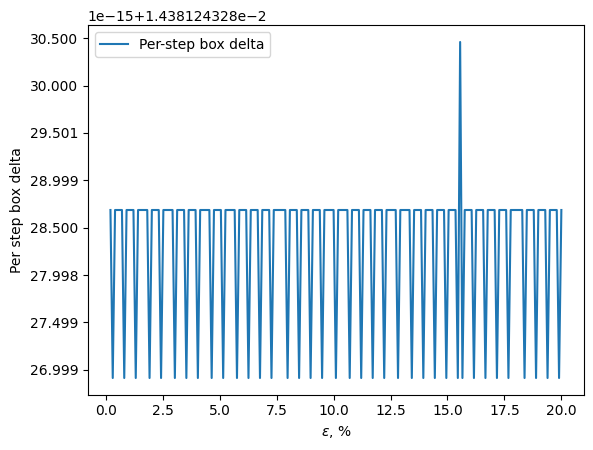

In [7]:
for d, dp in zip(deltas, deltas_percent):
    strain = np.array(range(len(delta)))
    strain = strain / strain.max() * 20

    plt.plot(strain[2:], d[2:], label="Per-step box delta")
    # plt.plot(strain[5:], dp[5:], label="Per-step strain")

plt.legend()
plt.ylabel("Per step box delta")
plt.xlabel(r"$\epsilon$, %")
plt.show()

In [8]:
deltas[0]

[0.014307898939399877,
 0.014381243280128686,
 0.014381243280128686,
 0.01438124328012691,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.01438124328012691,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.01438124328012691,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.01438124328012691,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.01438124328012691,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.01438124328012691,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.01438124328012691,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.014381243280128686,
 0.01438124328012691,
 0.014381243280128686,
 0.014381243280128686,
 0.0143812432801286